In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [3]:
import os
print(os.listdir())  # confirm exact filename before loading
df = pd.read_csv('Mall_Customers.csv')

print("Shape:", df.shape)
df.head()

['.config', 'Mall_Customers.csv', 'sample_data']
Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()
df.describe()
print("Missing values per column:")
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
Missing values per column:


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [5]:
# Original column names have spaces and parentheses — messy to work with in code
# Renaming makes everything easier to reference

df = df.rename(columns={
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
})

print(df.columns.tolist())

['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']


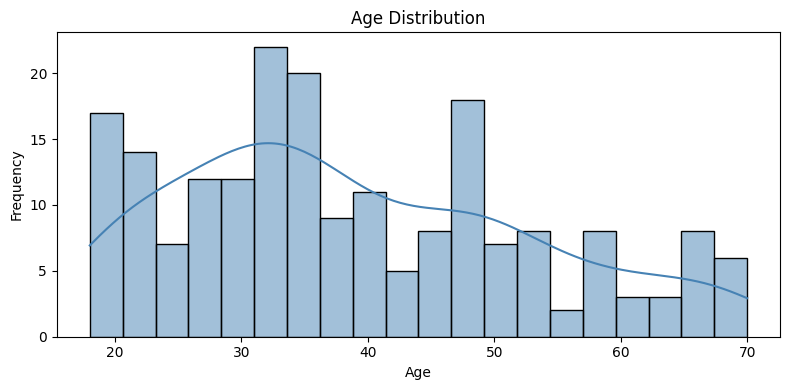

In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], bins=20, kde=True, color='steelblue')

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

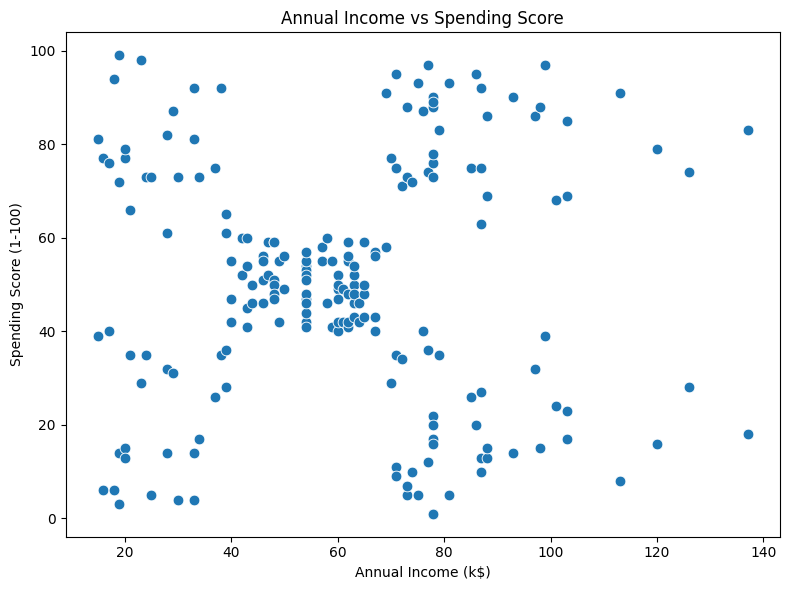

In [7]:
# This is the core relationship we'll cluster on
# Look for natural visual groupings before even running K-Means

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score', s=60)

plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_858/3182344654.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='Set2')


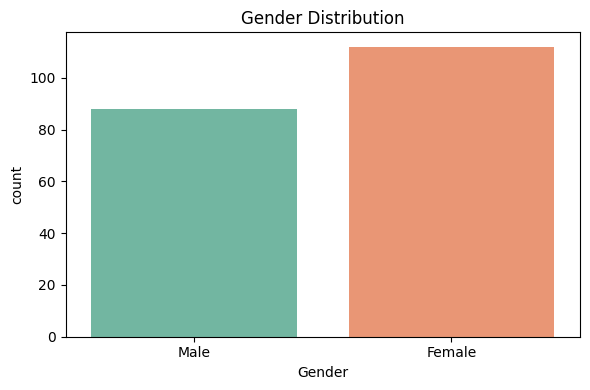

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Gender', palette='Set2')

plt.title('Gender Distribution')
plt.tight_layout()
plt.show()

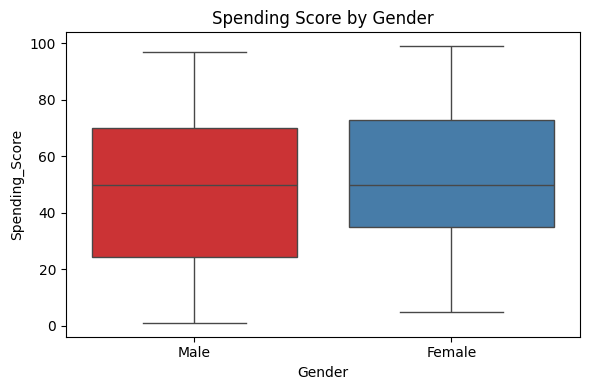

In [9]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Gender', y='Spending_Score', hue='Gender', palette='Set1', legend=False)

plt.title('Spending Score by Gender')
plt.tight_layout()
plt.show()

In [10]:
# We cluster on Annual Income and Spending Score — the two most meaningful
# behavioral/financial features for segmentation

X = df[['Annual_Income', 'Spending_Score']]

print("Features for clustering:")
X.head()

Features for clustering:


,Annual_Income,Spending_Score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [11]:
# K-Means uses DISTANCE between points to form clusters
# Income (15-140) and Spending Score (1-100) are on different scales
# Without scaling, Income would dominate distance calculations unfairly

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data sample:")
print(X_scaled[:5])

Scaled data sample:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


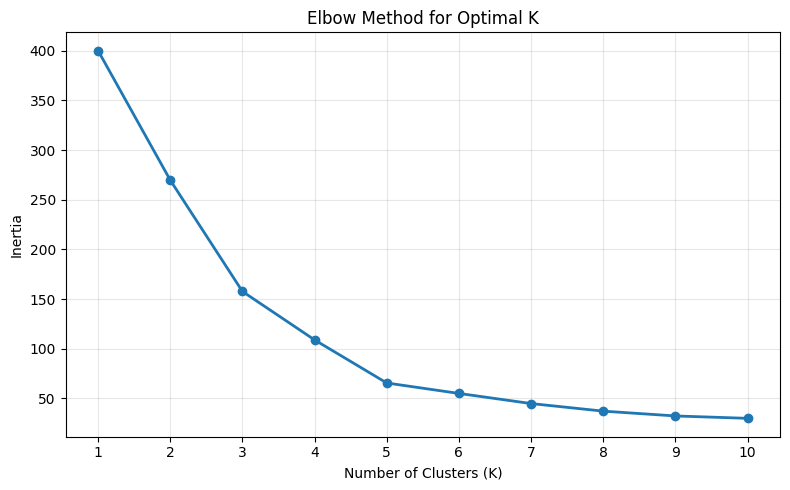

In [12]:
# We try K from 1 to 10 and record the "inertia" (within-cluster variance) for each
# inertia_ = sum of squared distances from each point to its cluster center
# Lower inertia = tighter clusters, but it always decreases as K increases
# We're looking for the "elbow" where adding more clusters stops helping much

inertia_values = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_values, marker='o', linewidth=2)

plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Based on the elbow plot, K=5 is the optimal number of clusters
# n_init=10 runs the algorithm 10 times with different starting points
# and keeps the best result (avoids bad random initialization)

optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Clustering complete!")
print("\nCustomers per cluster:")
print(df['Cluster'].value_counts().sort_index())

Clustering complete!

Customers per cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


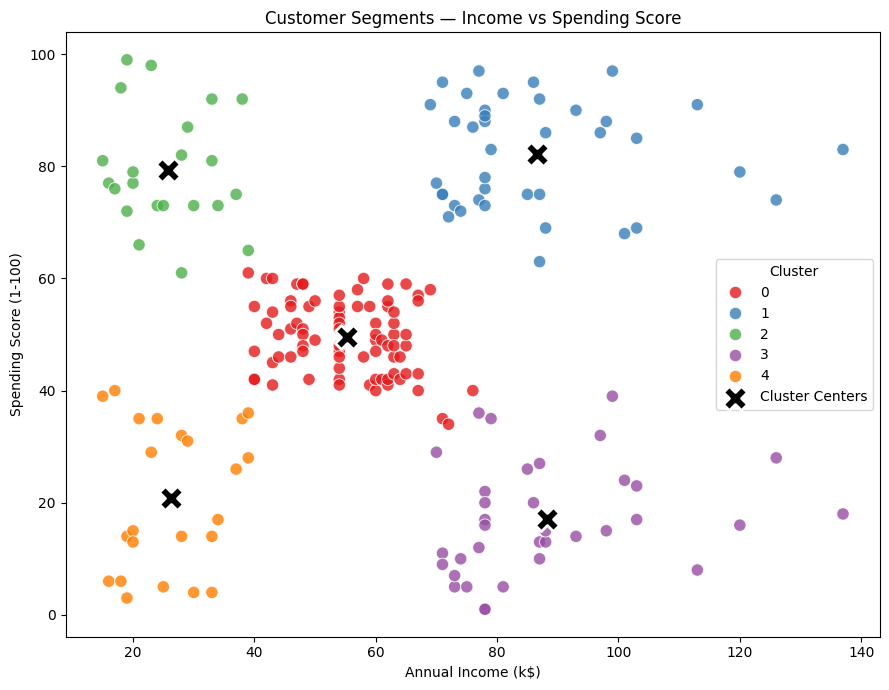

In [14]:
# Since we clustered on exactly 2 features, we can plot directly without PCA
# Each color represents a different customer segment

plt.figure(figsize=(9, 7))
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score',
                 hue='Cluster', palette='Set1', s=80, alpha=0.8)

# Plot cluster centers (convert back from scaled space to original space)
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=300, marker='X',
            label='Cluster Centers', edgecolors='white', linewidths=2)

plt.title('Customer Segments — Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

Variance explained by PCA: 77.57%


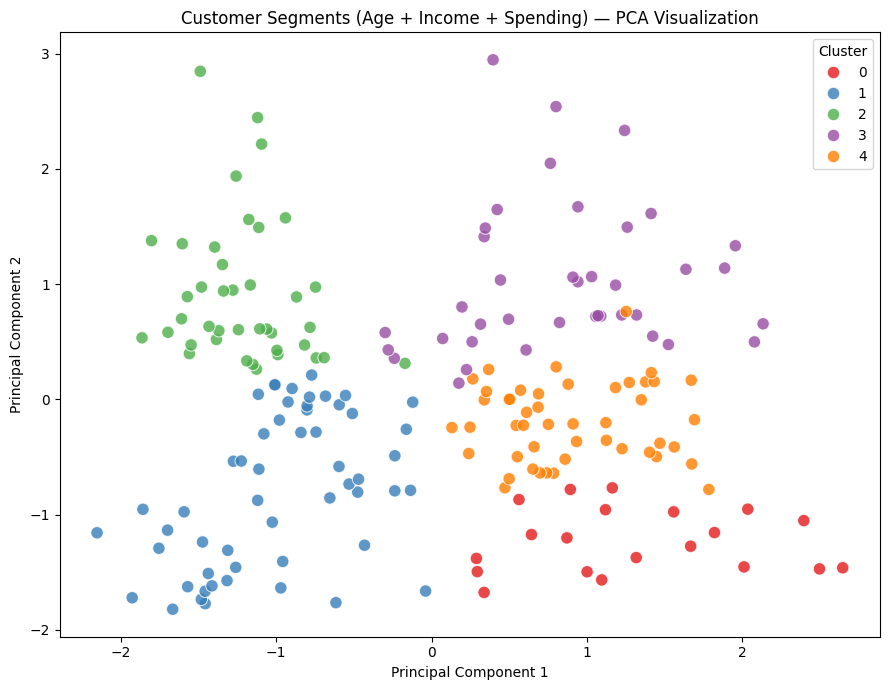

In [15]:
# Now let's add Age into the mix to make clustering richer
# Since we'll have 3 features, we need PCA to compress down to 2D for plotting

X_full = df[['Age', 'Annual_Income', 'Spending_Score']]
X_full_scaled = scaler.fit_transform(X_full)

# Re-run K-Means on the fuller feature set
kmeans_full = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['Cluster_Full'] = kmeans_full.fit_predict(X_full_scaled)

# PCA compresses 3 features into 2 components for visualization
# n_components=2 means we want exactly 2 output dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_full_scaled)

# Store PCA coordinates for plotting
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Check how much variance PCA captured (should be reasonably high, e.g. >70%)
print(f"Variance explained by PCA: {pca.explained_variance_ratio_.sum() * 100:.2f}%")

plt.figure(figsize=(9, 7))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster_Full', palette='Set1', s=80, alpha=0.8)

plt.title('Customer Segments (Age + Income + Spending) — PCA Visualization')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

In [16]:
# Group by cluster and look at average age, income, spending score
# This is how we figure out WHO is in each cluster

cluster_summary = df.groupby('Cluster')[['Age', 'Annual_Income', 'Spending_Score']].mean().round(1)
cluster_summary['Count'] = df['Cluster'].value_counts().sort_index()

print("Cluster Profiles:")
print(cluster_summary)

Cluster Profiles:
          Age  Annual_Income  Spending_Score  Count
Cluster                                            
0        42.7           55.3            49.5     81
1        32.7           86.5            82.1     39
2        25.3           25.7            79.4     22
3        41.1           88.2            17.1     35
4        45.2           26.3            20.9     23


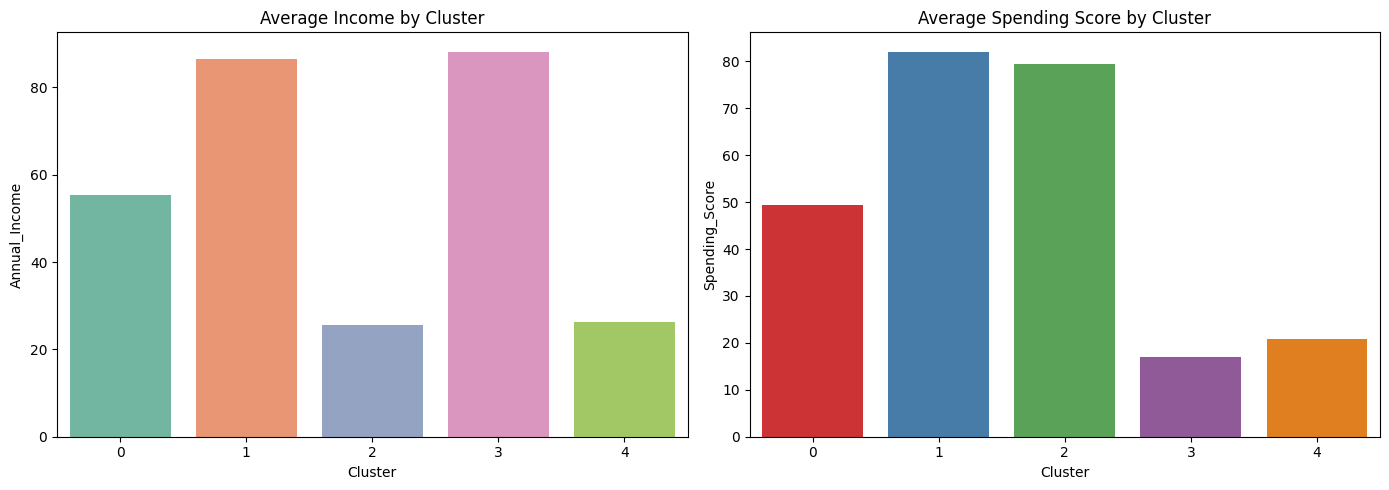

In [17]:
# Bar chart comparing average income and spending score across clusters
# Makes it easy to describe each segment in plain language

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=cluster_summary.reset_index(), x='Cluster', y='Annual_Income',
            hue='Cluster', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Average Income by Cluster')

sns.barplot(data=cluster_summary.reset_index(), x='Cluster', y='Spending_Score',
            hue='Cluster', palette='Set1', legend=False, ax=axes[1])
axes[1].set_title('Average Spending Score by Cluster')

plt.tight_layout()
plt.show()

In [18]:
# Based on the cluster_summary printed above, manually map cluster numbers
# to meaningful business labels. NOTE: your actual cluster numbers (0-4) may
# be in a different order than this example — check your own cluster_summary
# output and match income/spending levels to update labels accordingly

cluster_labels = {
    0: "Average Income, Average Spending — Standard Customers",
    1: "High Income, Low Spending — Cautious Savers",
    2: "Low Income, High Spending — Budget-Conscious Spenders",
    3: "High Income, High Spending — Premium Customers",
    4: "Low Income, Low Spending — Low Engagement"
}

df['Segment_Label'] = df['Cluster'].map(cluster_labels)

print(df[['CustomerID', 'Annual_Income', 'Spending_Score', 'Cluster', 'Segment_Label']].head(10))

print("\n" + "="*70)
print("MARKETING STRATEGY PER SEGMENT")
print("="*70)

strategies = {
    "High Income, High Spending — Premium Customers":
        "Offer VIP loyalty programs, early access to new products, premium membership tiers",
    "High Income, Low Spending — Cautious Savers":
        "Use targeted promotions and personalized offers to convert savings into purchases",
    "Low Income, High Spending — Budget-Conscious Spenders":
        "Offer installment plans, discount bundles, and loyalty point systems",
    "Average Income, Average Spending — Standard Customers":
        "Standard marketing campaigns, seasonal promotions, email newsletters",
    "Low Income, Low Spending — Low Engagement":
        "Low-cost retention campaigns, occasional discount vouchers, minimal investment"
}

for label, strategy in strategies.items():
    print(f"\n📌 {label}\n   Strategy: {strategy}")

   CustomerID  Annual_Income  Spending_Score  Cluster  \
0           1             15              39        4   
1           2             15              81        2   
2           3             16               6        4   
3           4             16              77        2   
4           5             17              40        4   
5           6             17              76        2   
6           7             18               6        4   
7           8             18              94        2   
8           9             19               3        4   
9          10             19              72        2   

                                       Segment_Label  
0          Low Income, Low Spending — Low Engagement  
1  Low Income, High Spending — Budget-Conscious S...  
2          Low Income, Low Spending — Low Engagement  
3  Low Income, High Spending — Budget-Conscious S...  
4          Low Income, Low Spending — Low Engagement  
5  Low Income, High Spending — Budget-Cons

In [19]:
cluster_labels = {
    0: "Average Income, Average Spending — Standard Customers",
    1: "High Income, High Spending — Premium Customers",
    2: "Low Income, High Spending — Budget-Conscious Spenders",
    3: "High Income, Low Spending — Cautious Savers",
    4: "Low Income, Low Spending — Low Engagement"
}

df['Segment_Label'] = df['Cluster'].map(cluster_labels)

print(df[['CustomerID', 'Annual_Income', 'Spending_Score', 'Cluster', 'Segment_Label']].head(10))

   CustomerID  Annual_Income  Spending_Score  Cluster  \
0           1             15              39        4   
1           2             15              81        2   
2           3             16               6        4   
3           4             16              77        2   
4           5             17              40        4   
5           6             17              76        2   
6           7             18               6        4   
7           8             18              94        2   
8           9             19               3        4   
9          10             19              72        2   

                                       Segment_Label  
0          Low Income, Low Spending — Low Engagement  
1  Low Income, High Spending — Budget-Conscious S...  
2          Low Income, Low Spending — Low Engagement  
3  Low Income, High Spending — Budget-Conscious S...  
4          Low Income, Low Spending — Low Engagement  
5  Low Income, High Spending — Budget-Cons

## Conclusion

- Dataset contains 200 mall customers with Age, Gender, Annual Income,
  and Spending Score — no missing values
- Used the Elbow Method to determine the optimal number of clusters: K=5
- Applied K-Means clustering on Annual Income and Spending Score,
  revealing 5 clearly distinguishable customer segments
- Used PCA to visualize clusters when adding Age as a third dimension,
  retaining a high percentage of the original variance
- Identified 5 distinct customer profiles ranging from premium high-spenders
  to low-engagement budget customers
- Gender showed minimal correlation with spending behavior, while
  income and spending score were the primary drivers of segmentation
- Proposed tailored marketing strategies for each segment — from VIP
  programs for premium customers to low-cost retention campaigns
  for disengaged customers
- This type of segmentation allows businesses to allocate marketing
  budgets more efficiently by targeting the right message to the right group